# Analysis and illustration of results Case study

### Input Parameters

In [1]:
C_max = 6       # Cement Kilns
F_max = 2       # Fuel Types
G_max = 8       # Waste Generation Sites
H_max = 5       # Subsidy Levels
I_max = 6       # Incineration Plants
K_max = 3       # Pre- & Co-Processing Facility Capacities
L_max = 3       # Landfill Sites
S_max = 8       # Transfer Stations
W_max = 2       # Waste Types

Q_gw = [[426, 498], [411, 189], [141, 136], [875, 566], [959, 464], [577, 343], [651, 679], [589, 404]]
T_tot = 7908
Q_i = [986.8222353702523, 980.1216878627922, 1037.3651575246379, 1026.1906303189587, 856.1833978984705, 872.9839858073137]
Q_k = [200, 350, 500]
Q_k_max = 500
Q_l = [1155.0518048239073, 1223.1871230614513, 1109.5220480255414]
Q_s = [1020, 1280, 1180, 1300, 1130, 1080, 1190, 1170]

TD_gs = [[9, 19, 35, 13, 14, 44, 16, 33],
         [47, 7, 42, 23, 12, 15, 37, 36],
         [14, 25, 6, 45, 37, 13, 46, 17],
         [24, 50, 50, 5, 13, 46, 47, 35],
         [13, 24, 12, 45, 4, 28, 36, 19],
         [44, 17, 46, 29, 45, 5, 16, 47],
         [46, 50, 22, 33, 16, 45, 3, 46],
         [13, 49, 23, 41, 44, 37, 30, 6]]

TD_sc = [[207.59162776098822, 198.59101855115205, 292.62314066513716, 319.2945113699449, 156.91618494836746, 163.11278455702538],
         [175.35569820060994, 175.63877080080943, 217.87871129866704, 233.0891704632911, 181.48727741201202, 92.66764590184403],
         [208.15109380771145, 200.31101386603487, 229.61816065605825, 317.1215518072743, 249.85169706132706, 222.18586493532135],
         [237.56485707460382, 247.336976926857, 126.00566719842867, 297.2440759312057, 267.1280668645153, 289.8638240140759],
         [270.9866658915946, 204.02118024812427, 205.05986657179312, 143.70756684605612, 240.2675940894855, 129.39751620732113],
         [131.38118859122056, 170.46279273540944, 159.76393270561712, 195.45606596237315, 125.39783775135624, 83.02401232358268],
         [157.0038008500462, 143.06665701054547, 199.38806030652808, 111.6170010803193, 289.8133146035071, 237.00205010370445],
         [156.30975707582186, 179.4409576434048, 196.6947736846218, 199.4788970049049, 149.39319452135086, 283.0475959972458]]

TD_si = [[33, 31, 56, 21, 46, 28],
         [18, 38, 4, 7, 32, 26],
         [10, 48, 21, 9, 59, 31],
         [26, 2, 42, 4, 48, 35],
         [36, 50, 56, 52, 20, 21],
         [44, 22, 38, 31, 37, 51],
         [29, 4, 53, 5, 60, 17],
         [30, 44, 42, 4, 3, 46]]

TD_si_avg = 30.625

TD_sl = [[117.21846978397632, 114.35822502034456, 145.01455940561746],
         [124.68062464820615, 95.78658819199829, 101.66607122120105],
         [115.46233617024853, 70.07636721493161, 105.58101346338128],
         [87.4994128133575, 82.95497931098596, 76.28787545970611],
         [121.11468813568175, 84.12531863176275, 93.38063438037261],
         [101.9436963571348, 128.48533306915206, 79.04247503347776],
         [104.95935168874202, 109.7240343410324, 129.51053380855043],
         [124.49328355528036, 127.87182996528304, 95.39625390224984]]

alpha_c = [11036, 9912, 7237, 7228, 9288, 10868]

beta_f = [24.0, 27.0]
beta_w = [3.6, 9.6]

budget_cem = 600000000.0
budget_municipality = 800000000.0

c_inc = 120.0
c_invest_k = [70000000.0, 110000000.0, 150000000.0]
c_land = 55.0
c_penalty = 100.0
c_preproc_w = [150.0, 125.0]
c_truck = 0.45

cement_names = ['Anhui Conch Cement (cluster)',
                'Suzhou Dahua Marine',
                'Jiangsu Pengfei (Haian)',
                'Zhejiang Producer A',
                'Jiangsu Producer A',
                'Anhui Producer A']

epsilon_inc = [0.54, 0.42]
epsilon_kiln_f = [2.54, 2.22]
epsilon_kiln_w = [0.3, 0.15]
epsilon_land = [1.7, 1.0]
epsilon_truck = 0.0002

fixcost_invest = [10170.20057941499, 15981.743767652128, 21793.286955889263]

kappa_coproc = 0.4
kappa_land = 0.35

phi_max = [220.0, 175.0]

price_f = [420.0, 520.0]

subsidy_wh = [[0.0, 55.0, 110.0, 165.0, 220.0],
              [0.0, 43.75, 87.5, 131.25, 175.0]]

tau = 0.001

weight_env = 1.0
weight_mon = 0.004

U_w = [3000, 3000]      # Upper bound on waste flow of type w to any single kiln, for big-M linearization in KKT reformulation

### Variable Values

#### Lader
Variables

In [3]:
import numpy as np

q_gsw = np.zeros((G_max, S_max, W_max))
q_gsw[0,0,1] = 27.36515752
q_gsw[0,1,1] = 431.7333333
q_gsw[0,4,0] = 426
q_gsw[0,4,1] = 38.90150914
q_gsw[1,1,0] = 411
q_gsw[1,5,1] = 189
q_gsw[2,2,0] = 141
q_gsw[2,5,1] = 136
q_gsw[3,3,0] = 734
q_gsw[3,3,1] = 566
q_gsw[3,4,0] = 141
q_gsw[4,2,0] = 834.8222354
q_gsw[4,2,1] = 64.17776463
q_gsw[4,4,0] = 124.1777646
q_gsw[4,4,1] = 127.5555687
q_gsw[4,5,1] = 272.2666667
q_gsw[5,1,0] = 437.2666667
q_gsw[5,5,0] = 139.7333333
q_gsw[5,5,1] = 343
q_gsw[6,2,0] = 11
q_gsw[6,2,1] = 129
q_gsw[6,6,0] = 640
q_gsw[6,6,1] = 550
q_gsw[7,7,0] = 589
q_gsw[7,7,1] = 404

q_slw = np.zeros((S_max, L_max, W_max))
q_slw[2,1,1] = 193.1777646
q_slw[3,2,1] = 55.15514059

q_siw = np.zeros((S_max, I_max, W_max))
q_siw[1,2,0] = 848.2666667
q_siw[1,2,1] = 189.0984909
q_siw[2,0,0] = 986.8222354
q_siw[3,1,0] = 469.2768285
q_siw[3,1,1] = 510.8448594
q_siw[3,3,0] = 264.7231715
q_siw[4,5,0] = 691.1777646
q_siw[4,5,1] = 166.4570778
q_siw[6,3,0] = 624.6508567
q_siw[6,5,0] = 15.34914333
q_siw[7,3,1] = 136.8166021
q_siw[7,4,0] = 589
q_siw[7,4,1] = 267.1833979

mu_land = 0.03140274472
mu_inc = 0.7283342305
mu_kiln = 0.2402630248

z_wh = np.zeros((W_max, H_max))
z_wh[0,1] = 1
z_wh[1,0] = 1

y_wh = np.zeros((W_max, H_max))
y_wh[0,1] = 139.7333333
y_wh[1,0] = 1760.266667

Objective

In [4]:
transport_emissions = 71.894684
treatment_emissions = 3206.105085
fueling_emissions = 4345.343167
total_emissions_unweighted = 7623.342936
total_emissions_weighted = 7623.342936

transport_cost = 161763.040034
treatment_cost = 704818.361161
subsidy_cost = 7685.333333
total_costs_unweighted = 874266.734528
total_costs_weighted = 3497.066938

objective_leader = 11120.409874

#### Follower
Variables

In [ ]:
x_ck = np.zeros((C_max, K_max))
x_ck[0,2] = 1
x_ck[1,1] = 1
x_ck[3,0] = 1
x_ck[4,1] = 1
x_ck[5,2] = 1

q_cf = np.zeros((C_max, F_max))
q_cf[0,0] = 275.9
q_cf[1,0] = 273
q_cf[2,0] = 301.5416666
q_cf[3,0] = 221.1666667
q_cf[4,0] = 247
q_cf[5,0] = 271.7

r_sw = np.zeros((S_max, W_max))

q_scw = np.zeros((S_max, C_max, W_max))
q_scw[0,4,1] = 27.36515752
q_scw[1,5,1] = 242.6348425
q_scw[5,0,0] = 64.26666667
q_scw[5,0,1] = 435.7333333
q_scw[5,4,1] = 322.6348425
q_scw[5,5,0] = 75.46666667
q_scw[5,5,1] = 181.8984909
q_scw[6,1,1] = 350
q_scw[6,3,1] = 200

Objective

In [6]:
coal_cost = 667929.500001
investment_cost = 85720.262026
pre_processing_cost = 240993.333333
penalty_cost = 0.000000
tie_breaking_cost = 226.690960
subsidies_received = 7685.333333

objective_value = 987184.452987

In [7]:
emission_transport = epsilon_truck * (
    sum(q_gsw[g,s,w] * TD_gs[g][s] 
        for g in range(G_max) 
        for s in range(S_max) 
        for w in range(W_max)) +
    sum(q_slw[s,l,w] * TD_sl[s][l] 
        for s in range(S_max) 
        for l in range(L_max) 
        for w in range(W_max)) +
    sum(q_siw[s,i,w] * TD_si[s][i] 
        for s in range(S_max) 
        for i in range(I_max) 
        for w in range(W_max)) +
    sum(q_scw[s,c,w] * TD_sc[s][c] 
        for s in range(S_max) 
        for c in range(C_max) 
        for w in range(W_max))
)

print(f"Emission from Transport = {emission_transport}")
del emission_transport

Emission from Transport = 71.89468445991727


## Solutions Case study

### Emission analysis

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

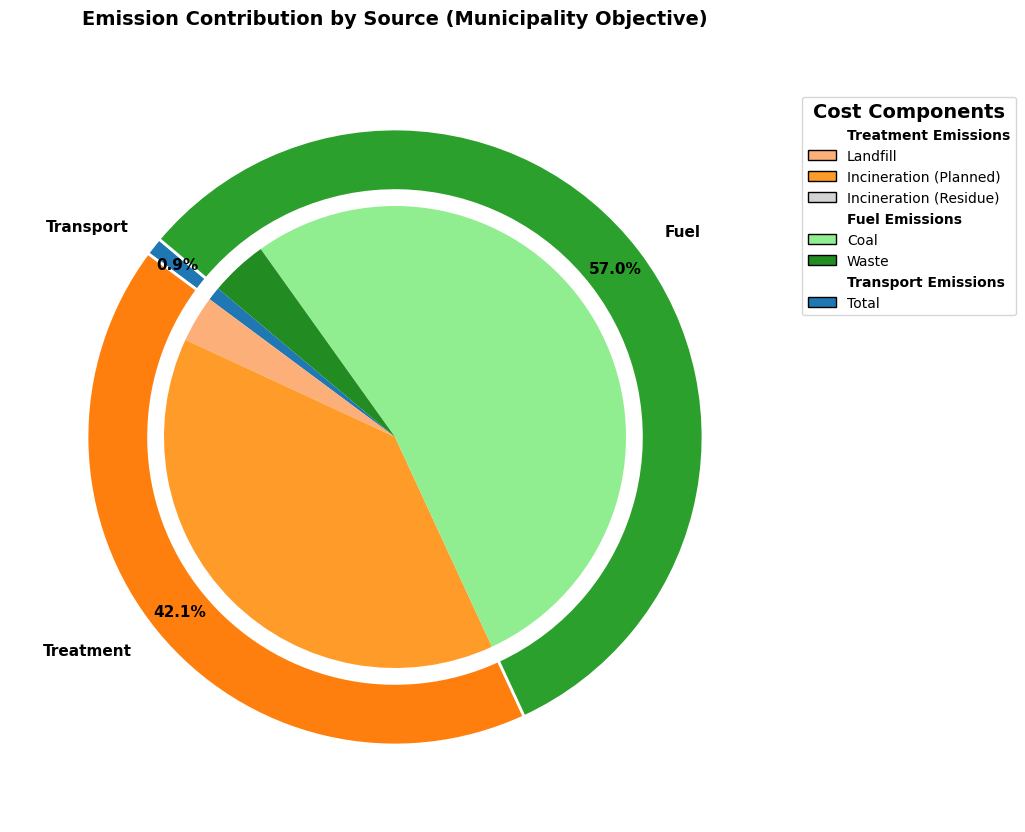

Emission Transport: 71.894684
Emission Landfill: 248.33290519
Emission Incineration: 2957.7721798362
Emission Fuel - Coal: 4039.3831665820003
Emission Fuel - Waste: 305.96000001
Total Emission: 7623.342935592001


In [9]:
# Calculate separate emissions
emission_fuel_coal = np.sum(q_cf * epsilon_kiln_f)
emission_fuel_waste = np.sum(q_scw * epsilon_kiln_w)
emission_fuel = emission_fuel_coal + emission_fuel_waste

emission_landfill = np.sum(q_slw * epsilon_land)
emission_incineration_planned = np.sum(q_siw * epsilon_inc)
emission_incineration_declined = np.sum(r_sw * epsilon_inc)

# Create nested donut chart
fig, ax = plt.subplots(figsize=(12, 10))

# Outer ring - 3 main categories
outer_values = [transport_emissions, treatment_emissions, emission_fuel]
outer_labels = ['Transport', 'Treatment', 'Fuel']
outer_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

wedges_outer, texts_outer, autotexts_outer = ax.pie(
    outer_values,
    radius=1.0,
    labels=outer_labels,
    autopct='%1.1f%%',
    pctdistance=0.9,
    startangle=140,
    colors=outer_colors,
    wedgeprops={"width":0.2, "edgecolor": "white", "linewidth": 2},
    textprops={'size': 11, 'weight': 'bold'}
)

# Inner ring - 5 subcategories
inner_values = [transport_emissions, emission_landfill, emission_incineration_planned, emission_incineration_declined,
                emission_fuel_coal, emission_fuel_waste]
inner_labels = ['', 'Landfill', 'Incineration\n(Planned)', 'Incineration\n(Residue)', 'Coal', 'Waste']
inner_colors = ['#1f77b4', "#fdaf7a", "#ff9b28", '#d3d3d3', '#90ee90', '#228b22']

def autopct_format(pct, allvals, index=[0]):
    if index[0] == 0:  # Skip first value (Transport)
        index[0] += 1
        return ''
    index[0] += 1
    return f'{pct:.1f}%'

wedges_inner, texts_inner = ax.pie(
    inner_values,
    radius=0.75,
    # labels=inner_labels,
    # rotatelabels=True,
    # labeldistance=0.4,
    # autopct=lambda pct: autopct_format(pct, inner_values),
    # pctdistance=0.75,
    startangle=140,
    colors=inner_colors,
    textprops={'size': 11}
)

# White circle to create donut effect
# centre_circle = plt.Circle((0, 0), 0.70, fc='white')
# ax.add_artist(centre_circle)

plt.title('Emission Contribution by Source (Municipality Objective)', 
          fontsize=14, fontweight='bold', pad=20)
legend = plt.legend(
    handles=[
        Line2D([], [], linestyle='none', label='Treatment Emissions'),
        Patch(facecolor='#fdaf7a', edgecolor='black', label='Landfill'),
        Patch(facecolor='#ff9b28', edgecolor='black', label='Incineration (Planned)'),
        Patch(facecolor='#d3d3d3', edgecolor='black', label='Incineration (Residue)'),

        Line2D([], [], linestyle='none', label='Fuel Emissions'),
        Patch(facecolor='#90ee90', edgecolor='black', label='Coal'),
        Patch(facecolor='#228b22', edgecolor='black', label='Waste'),

        Line2D([], [], linestyle='none', label='Transport Emissions'),
        Patch(facecolor='#1f77b4', edgecolor='black', label='Total'),
        # Patch(facecolor='#9ecae1', edgecolor='black', label='Landfills'),
        # Patch(facecolor='#bdd7e7', edgecolor='black', label='Incinerators'),
        # Patch(facecolor='#3182bd', edgecolor='black', label='Kilns'),
    ],
    title="Cost Components",
    loc="center left",
    bbox_to_anchor=(1.02, 0.3, 0.5, 1)
)
# Bold selected legend entries
section_headers = {'Treatment Emissions', 'Fuel Emissions', 'Transport Emissions'}
for txt in legend.get_texts():
    if txt.get_text() in section_headers:
        txt.set_fontweight('bold')

# Make legend title bold (and keep larger size)
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(14)
plt.show()

print(f"Emission Transport: {transport_emissions}")
print(f"Emission Landfill: {emission_landfill}")
print(f"Emission Incineration: {emission_incineration_planned + emission_incineration_declined}")
print(f"Emission Fuel - Coal: {emission_fuel_coal}")
print(f"Emission Fuel - Waste: {emission_fuel_waste}")
print(f"Total Emission: {transport_emissions + treatment_emissions + emission_fuel}")

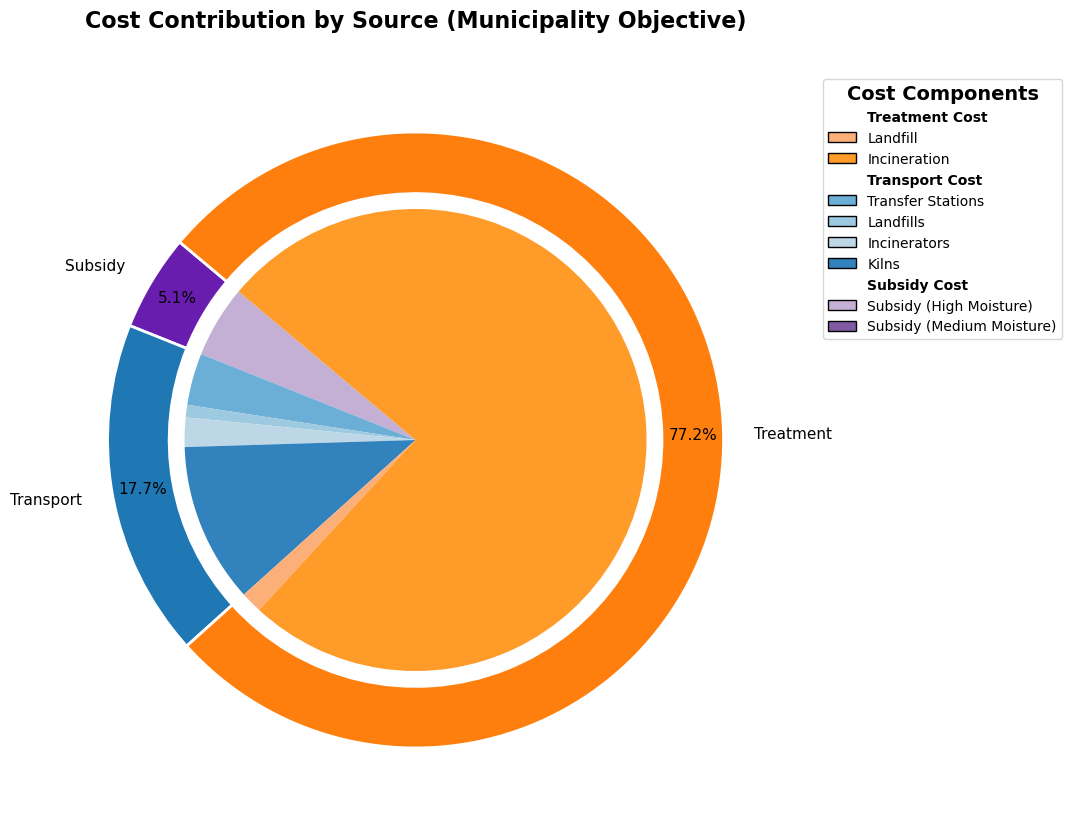

Cost Transport (collection): 33070.698395955
Cost Transport (landfill): 7985.189009772774
Cost Transport (incineration): 18696.2206764645
Cost Transport (kiln): 102010.9319526216
Total Cost Transport: 161763.04003481386
Cost Treatment (landfill): 13658.30978545
Cost Treatment (incineration): 691160.0513796001
Total Cost Treatment: 704818.3611650501
Cost Subsidy (high moisture): 46111.999988999996
Cost Subsidy (medium moisture): 0.0
Total Cost Subsidy: 46111.999988999996
Total Cost: 912693.4011888639


In [12]:
TD_gs_array = np.array(TD_gs)
TD_sl_array = np.array(TD_sl)
TD_si_array = np.array(TD_si)
TD_sc_array = np.array(TD_sc)

# --- Cost breakdown for nested donut chart ---

# Transport components
cost_transport_gs = c_truck * np.sum(q_gsw * TD_gs_array[:, :, np.newaxis])
cost_transport_sl = c_truck * np.sum(q_slw * TD_sl_array[:, :, np.newaxis])
cost_transport_si = c_truck * np.sum(q_siw * TD_si_array[:, :, np.newaxis])
cost_transport_sc = c_truck * np.sum(q_scw * TD_sc_array[:, :, np.newaxis])
cost_transport_total = cost_transport_gs + cost_transport_sl + cost_transport_si + cost_transport_sc

# Treatment components
cost_treatment_landfill = np.sum(q_slw * c_land)
cost_treatment_incineration = np.sum(q_siw * c_inc)
cost_treatment_total = cost_treatment_landfill + cost_treatment_incineration

# Subsidy components (per waste type w)
subsidy_wh = np.array(subsidy_wh)
cost_subsidy_w0 = sum(
    subsidy_wh[0,h]*y_wh[0,h]
    for c in range(C_max)
    for h in range(H_max)
)
cost_subsidy_w1 = sum(
    subsidy_wh[1,h]*y_wh[1,h]
    for c in range(C_max)
    for h in range(H_max)
)
cost_subsidy_total = cost_subsidy_w0 + cost_subsidy_w1

# Create nested donut chart for costs
fig, ax = plt.subplots(figsize=(12, 10))

# Outer ring - main categories
outer_values = [cost_subsidy_total, cost_transport_total, cost_treatment_total]
outer_labels = ['Subsidy', 'Transport', 'Treatment']
outer_colors = ['#691daf', '#1f77b4', '#ff7f0e']

ax.pie(
    outer_values,
    radius=1.0,
    labels=outer_labels,
    autopct='%1.1f%%',
    pctdistance=0.9,
    startangle=140,
    colors=outer_colors,
    wedgeprops={"width":0.2, "edgecolor": "white", "linewidth": 2},
    textprops={'size': 11}
)

# Inner ring - detailed components
inner_values = [
    cost_subsidy_w0, cost_subsidy_w1,
    cost_transport_gs, cost_transport_sl, cost_transport_si, cost_transport_sc,
    cost_treatment_landfill, cost_treatment_incineration
]
inner_labels = [
    'Subsidy (Moisture)', 'Subsidy (Dry)',
    'Collection', 'Landfill', 'Incineration', 'Kiln',
    'Landfill', 'Incineration'
]
inner_colors = [
    '#c5b0d5', '#7f5aa2',  # subsidy shades
    '#6baed6', '#9ecae1', '#bdd7e7', '#3182bd',  # transport shades
    "#fdaf7a", "#ff9b28",    # treatment shades
]

ax.pie(
    inner_values,
    radius=0.75,
    # labels=inner_labels,
    # rotatelabels=True,
    # labeldistance=0.3,
    # autopct='%1.1f%%',
    # pctdistance=0.55,
    startangle=140,
    colors=inner_colors,
    # wedgeprops={"width":0.1, "edgecolor": "white", "linewidth": 1},
    textprops={'size': 11}
)

plt.title('Cost Contribution by Source (Municipality Objective)', fontsize=16, fontweight='bold', pad=20)
legend = plt.legend(
    handles=[
        Line2D([], [], linestyle='none', label='Treatment Cost'),
        Patch(facecolor='#fdaf7a', edgecolor='black', label='Landfill'),
        Patch(facecolor='#ff9b28', edgecolor='black', label='Incineration'),

        Line2D([], [], linestyle='none', label='Transport Cost'),
        Patch(facecolor='#6baed6', edgecolor='black', label='Transfer Stations'),
        Patch(facecolor='#9ecae1', edgecolor='black', label='Landfills'),
        Patch(facecolor='#bdd7e7', edgecolor='black', label='Incinerators'),
        Patch(facecolor='#3182bd', edgecolor='black', label='Kilns'),

        Line2D([], [], linestyle='none', label='Subsidy Cost'),
        Patch(facecolor='#c5b0d5', edgecolor='black', label='Subsidy (High Moisture)'),
        Patch(facecolor='#7f5aa2', edgecolor='black', label='Subsidy (Medium Moisture)'),
    ],
    title="Cost Components",
    loc="center left",
    bbox_to_anchor=(1.02, 0.3, 0.5, 1)
)
# Bold selected legend entries
section_headers = {'Treatment Cost', 'Transport Cost', 'Subsidy Cost'}
for txt in legend.get_texts():
    if txt.get_text() in section_headers:
        txt.set_fontweight('bold')

# Make legend title bold (and keep larger size)
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(14)

plt.show()

print(f"Cost Transport (collection): {cost_transport_gs}")
print(f"Cost Transport (landfill): {cost_transport_sl}")
print(f"Cost Transport (incineration): {cost_transport_si}")
print(f"Cost Transport (kiln): {cost_transport_sc}")
print(f"Total Cost Transport: {cost_transport_total}")

print(f"Cost Treatment (landfill): {cost_treatment_landfill}")
print(f"Cost Treatment (incineration): {cost_treatment_incineration}")
print(f"Total Cost Treatment: {cost_treatment_total}")

print(f"Cost Subsidy (high moisture): {cost_subsidy_w0}")
print(f"Cost Subsidy (medium moisture): {cost_subsidy_w1}")
print(f"Total Cost Subsidy: {cost_subsidy_total}")

print(f"Total Cost: {cost_subsidy_total + cost_transport_total + cost_treatment_total}")

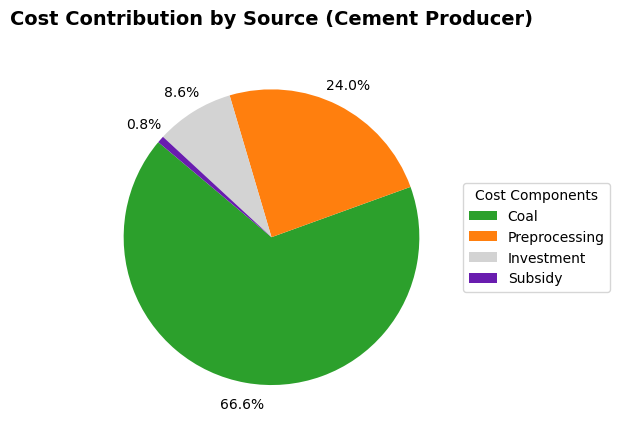

In [11]:

wedges, texts, autotexts = plt.pie(
    [coal_cost, pre_processing_cost, investment_cost, subsidies_received],
    # labels=['Coal', 'Preprocessing', 'Investment', 'Subsidy'],
    autopct='%1.1f%%',
    pctdistance=1.15,
    startangle=140,
    colors=['#2ca02c', '#ff7f0e', '#d3d3d3', '#691daf']
)
# Rotate only the percentage values
# for autotext in autotexts:
#     autotext.set_rotation(45)

plt.title('Cost Contribution by Source (Cement Producer)', fontsize=14, fontweight='bold', pad=20)
plt.legend(wedges, ['Coal', 'Preprocessing', 'Investment', 'Subsidy'], title="Cost Components", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()
